**Project:** Data Mining II (2025/26)

**Group Number:** 12

**Members:**
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929

**Project Overview**

In recent years, nonprofit organizations have faced a growing challenge: while charitable causes have multiplied, public tolerance for repeated, generic solicitations has significantly decreased, often leading to donor fatigue and long-term disengagement. To address this issue, the Civic Support Alliance (CSA)—a federation representing multiple humanitarian and social aid programs—seeks to modernize its fundraising strategy. Rather than launching blanket campaigns across their entire database, the organization aims to transition to a highly targeted approach. The goal is to maximize operational efficiency and maintain donor respect by contacting fewer, but more receptive, individuals. 

As data scientists, our team has been tasked with building a predictive machine learning system using historical demographic, interaction, and donation data accumulated from past campaigns. The primary objective is to accurately answer a fundamental question: Will this person donate if contacted? 

**Notebook Introduction**

In this notebook, we will develop K-Nearest Neighbors models, we will find parameter regions using our hold-out method splits as explained in the Modeling Tools notebook to test and we will then perform a parameter search to try and maximize performances.

**Benchmarks**

As the goal of this project is to help the CSA create and improve a targeted approach to donors with the goal of maximizing donations, we will use 2 baseline benchmarks as the minimum any model must achieve to be a good model:
+ Random prediction, which in a dataset with the imbalance present in the CSA's data yield an **F1-Score of ~0.34**
+ Predicting all 1, which is essentially, telling the CSA to keep sending out the camapaign to everyone. This is obviously not the desire of the CSA and as such the goal is to create models that can avoid this. Predicting all 1 in a dataset with this imbalance yields an **F1-Score of 0.4**

**Table of contents**<a id='toc0_'></a>    
1. [Imports](#toc1_)    
2. [Defining the Pipeline](#toc2_)    
3. [Base Model](#toc3_)    
4. [Model with Threshold optimization](#toc4_)    
5. [Number of Neighbors](#toc5_)    
6. [Distance Metric](#toc6_)    
7. [Weight](#toc7_)    
8. [Parameter Search](#toc8_)    
9. [Test set prediction](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Imports](#toc0_)

In this section we're importing everything we need, libraries and tools.

In [ ]:
from sklearnex import patch_sklearn
patch_sklearn()
from utils_modeling import (OutlierClipper, CategoricalFeatureSelector, NumericalFeatureSelector, FeatureEngineer, DataCleaner, run_parameter_search)
import os
if os.getcwd() != 'c:\\Users\\dinis\\OneDrive\\Ambiente de Trabalho\\Faculdade - MGI-BI\\1º ano\\2º Semestre\\Data Mining II\\Project\\DM2_Project':
    %cd ..
import numpy as np
import pandas as pd
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")
SEED=23
pd.options.display.max_columns = None

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project


In [ ]:
train = pd.read_csv('Files/donors_train.csv')
with open('Files/Pickle Files/model_testing_skf.pkl', 'rb') as file:
    model_testing_skf = pickle.load(file)
with open('Files/Pickle Files/data_cleaner.pkl', 'rb') as file:
    data_cleaner = pickle.load(file)
with open('Files/Pickle Files/X_train_preprocessed.pkl', 'rb') as file:
    X_train_preprocessed = pickle.load(file)
with open('Files/Pickle Files/X_val_preprocessed.pkl', 'rb') as file:
    X_val_preprocessed = pickle.load(file)
with open('Files/Pickle Files/y_train.pkl', 'rb') as file:
    y_train = pickle.load(file)
with open('Files/Pickle Files/y_val.pkl', 'rb') as file:
    y_val = pickle.load(file)

In [ ]:
X = train.drop('TARGET_B', axis=1)
y = train['TARGET_B']

# 2. <a id='toc2_'></a>[Defining the Pipeline](#toc0_)

We're first going to start by defining the pipeline we're gonna use as a base. This is the pipeline introduced in the Modeling Tools notebook, now with a KNN model.

In [ ]:
# Categorical Feature Sub-Pipeline
# This is the part that handles the categorical columns, performing
# mode imputation, feature selection using our custom CategoricalFeatureSelector
# and finally one-hot encoding the features.
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('feature_selection',  CategoricalFeatureSelector()),
    # 3. Your specialized encoding (OneHot/Target) now receives imputed integers
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

# Numerical Feature Sub-Pipeline
# Here we take care of our numerical features, starting with outlier clipping and feature
# creation using our custom transformer, then scaling data, so that it can then 
# be imputed and numerical feature selection can be performed
num_pipe = Pipeline([
    ('clipper', OutlierClipper()),
    ('feature_engineer', FeatureEngineer()),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer()),
    ('feature_selection', NumericalFeatureSelector(random_state=SEED))
])

# Here we use a ColumnTransformer with column selectors to perform the split
# between numerical and categorical data, so that each subset can be directed
# to the appropriate sub-pipeline
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, make_column_selector(dtype_exclude=[np.number])),
    ('num_section', num_pipe, make_column_selector(dtype_include=[np.number])),
],
verbose_feature_names_out=False)
#  

 
# Final Pipeline
knn_pipe = Pipeline([
    ('cleaner', data_cleaner),
    ('preprocessing', preprocessor),
    ('model', TunedThresholdClassifierCV(KNeighborsClassifier(),
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED
                                         )) 
])

# We use the set_output to pandas so that intermediate transformers can use column
# names, since some of the default scikit-learn transformers by default return 
# Numpy arrays, which obviously don't have column names.
knn_pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

Now let's start looking at models and results.

# 3. <a id='toc3_'></a>[Base Model](#toc0_)

We'll start by testing a base, unchanged model.

In [ ]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_preprocessed, y_train)
base_pred_train = knn_base.predict(X_train_preprocessed)
base_pred_val = knn_base.predict(X_val_preprocessed)
print(f"Base Model F1-Score in Training: {f1_score(y_train, base_pred_train)}")
print(f"Base Model F1-Score in Validation: {f1_score(y_val, base_pred_val)}")

Base Model F1-Score in Training: 0.4085750315258512
Base Model F1-Score in Validation: 0.19328585961342828


Right away, it becomes clear that the default KNN model without threshold optimization performs very poorly, significantly worse than random or all 1 prediction. We'll now see the impact of threshold optimization on the performance.

# 4. <a id='toc4_'></a>[Model with Threshold optimization](#toc0_)

In [ ]:
knn_thresh_opt = TunedThresholdClassifierCV(KNeighborsClassifier(),
                                            n_jobs=-1,
                                            scoring='f1',
                                            random_state=SEED)
knn_thresh_opt.fit(X_train_preprocessed, y_train)
thresh_op_pred_train = knn_thresh_opt.predict(X_train_preprocessed)
thresh_op_pred_val = knn_thresh_opt.predict(X_val_preprocessed)
print(f"Threshold Oprimized Base Model F1-Score in Training: {f1_score(y_train, thresh_op_pred_train)}")
print(f"Threshold Oprimized Base Model F1-Score in Validation: {f1_score(y_val, thresh_op_pred_val)}")
print(f'Optmized Threshold: {knn_thresh_opt.best_threshold_}')

Threshold Oprimized Base Model F1-Score in Training: 0.4
Threshold Oprimized Base Model F1-Score in Validation: 0.4
Optmized Threshold: 0.0


Using the threshold optimizer shows us that the base KNN model has no predictive power, since the threshold is optimized to 0, meaning all predictions are 1. This tells us we need to start evaluating the parameters of the KNN model to look for opportunities to improve performance.

# 5. <a id='toc5_'></a>[Number of Neighbors](#toc0_)
The first parameter we're going to look at is the number of neighbors, given the relatively large size of the dataset and the level of complexity of the problem we're going test 1 to 150 to get the best picture we can. We're gonna use the preprocessed train and validation sets, since the goal here is to get a a decent idea quickly.

In [ ]:
k_list = np.arange(1, 150)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in tqdm(k_list):
    knn_model = TunedThresholdClassifierCV(KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1),
        n_jobs=-1,
        scoring='f1',
        random_state=SEED)
    knn_model.fit(X_train_preprocessed, y_train)
    train_pred = knn_model.predict(X_train_preprocessed)
    val_pred = knn_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

  0%|          | 0/149 [00:00<?, ?it/s]

Best number of neighbors: 58
Mean F1 score in train with 58 neighbors: 0.435574
Mean F1 score in validation with 58 neighbors: 0.408627


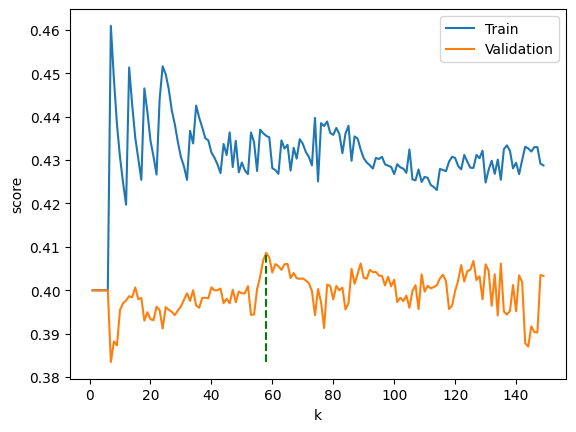

In [ ]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()

In [ ]:
knn_58 = TunedThresholdClassifierCV(KNeighborsClassifier(
        n_neighbors=58,
        n_jobs=-1),
        n_jobs=-1,
        scoring='f1')
knn_58.fit(X_train_preprocessed, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",KNeighborsCla..._neighbors=58)
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'f1'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",None
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",58
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape 

In [ ]:
knn_58.best_threshold_

np.float64(0.2001044932079415)

The best number of neigbors was 58 with and F1-Score in validation of 0.408627 and not much overfitting (0.435574 in training), we'll test values around this when performing the parameter search. This means that this model already performs better in validation that the two baselines we set above. We can see the threshold optimizer no longer optimizes the threshold to be 0, but it still lowers it significantly from 0.5 to produce more predicted positives.

# 6. <a id='toc6_'></a>[Distance Metric](#toc0_)

Now, let's test the impact of changing the value of p, which changes the distance metric used, we'll test p=1 which is the Manhattan distance, p=2 (default) which is the euclidean distance and p=3 just to see the impact of increasing the value of p beyond 2.

In [ ]:
p_list = np.arange(1, 4)
scores_train = []
scores_val = []
high_score=0
nof=0
for p in tqdm(p_list):
    knn_model = TunedThresholdClassifierCV(KNeighborsClassifier(
        n_neighbors=58,
        p=p,
        n_jobs=-1),
        n_jobs=-1,
        scoring='f1',
        random_state=SEED)
    knn_model.fit(X_train_preprocessed, y_train)
    train_pred = knn_model.predict(X_train_preprocessed)
    val_pred = knn_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = p_list[p-1]


print("Best p: %d" %nof)
print("Mean F1 score in train with %d p: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d p: %f" % (nof, high_score))

  0%|          | 0/3 [00:00<?, ?it/s]

Best p: 2
Mean F1 score in train with 2 p: 0.435574
Mean F1 score in validation with 2 p: 0.408627


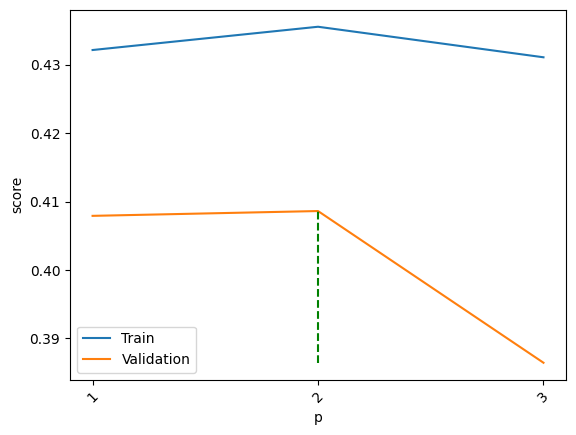

In [ ]:
plt.plot(p_list, scores_train, label='Train')
plt.plot(p_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(p_list, rotation=45)
plt.xlabel('p')
plt.ylabel('score')
plt.legend()

plt.show()

The scores with Manhattan and Euclidean distance are similar, but the scores for p=3 are significantly worse, as such, and since p=3 massivey icreases runtime, we will only test p=1 and p=2 in our parameter search.

# 7. <a id='toc7_'></a>[Weight](#toc0_)

The last parameter we're gonna look at is the weights parameter which affects the weight of neighborhood point used in prediction. From the sklearn documentation:
+ uniform : All points in each neighborhood are weighted equally. This is the default, so we already know how it performs.
+ distance : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.

In [ ]:
knn_model_distance = TunedThresholdClassifierCV(KNeighborsClassifier(
    n_neighbors=58,
    weights='distance',
    n_jobs=-1),
    n_jobs=-1,
    scoring='f1',
    random_state=SEED)
knn_model_distance.fit(X_train_preprocessed, y_train)
train_pred = knn_model_distance.predict(X_train_preprocessed)
val_pred = knn_model_distance.predict(X_val_preprocessed)
print(f'Train F1: {f1_score(y_train, train_pred)}')
print(f'Validation F1: {f1_score(y_val, val_pred)}')

Train F1: 1.0
Validation F1: 0.4055727554179567


Using distance based weghts for neighborhood influence on prediction slightly decreases the validation scores and maximizes the training score to 1, generating a situation of massive overfitting. Due to this we won't test it in the parameter search.

# 8. <a id='toc8_'></a>[Parameter Search](#toc0_)

It's now time to run the gridsearch, using our run_parameter_search function, based on the parameter regions we've found so far.

In [ ]:
# Defining the percentile profiles to use for testing percentile based clipping.
restricted_profile = {
    "DONOR_AGE": {"lower": 0.0203, "upper": 0.9931},
    "MEDIAN_HOME_VALUE": {"lower": 0.9748, "upper": None},
    "MEDIAN_HOUSEHOLD_INCOME": {"lower": 0.978, "upper": None},
    "PCT_OWNER_OCCUPIED": {"lower": 0.048, "upper": None},
    "PER_CAPITA_INCOME": {"lower": 0.0146, "upper": None},
    "PCT_ATTRIBUTE1": {"lower": None, "upper": None},
    "PCT_ATTRIBUTE2": {"lower": 0.0541, "upper": 0.9862},
    "PCT_ATTRIBUTE3": {"lower": 0.9878, "upper": None},
    "PCT_ATTRIBUTE4": {"lower": 0.9824, "upper": None},
    "RECENT_RESPONSE_PROP": {"lower": 0.9896, "upper": None},
    "RECENT_AVG_GIFT_AMT": {"lower": 0.9962, "upper": None},
    "RECENT_CARD_RESPONSE_PROP": {"lower": 0.9942, "upper": None},
    "RECENT_AVG_CARD_GIFT_AMT": {"lower": 0.997, "upper": None},
    "RECENT_RESPONSE_COUNT": {"lower": 0.9743, "upper": None},
    "RECENT_CARD_RESPONSE_COUNT": {"lower": 0.9344, "upper": None},
    "MONTHS_SINCE_LAST_PROM_RESP": {"lower": None, "upper": 0.9977},
    "LIFETIME_PROM": {"lower": 0.9967, "upper": None},
    "LIFETIME_GIFT_AMOUNT": {"lower": 0.9762, "upper": None},
    "LIFETIME_GIFT_COUNT": {"lower": 0.9645, "upper": None},
    "LIFETIME_MAX_GIFT_AMT": {"lower": 0.9827, "upper": None},
    "LIFETIME_MIN_GIFT_AMT": {"lower": 0.989, "upper": None},
    "LAST_GIFT_AMT": {"lower": 0.9874, "upper": None},
    "CARD_PROM_12": {"lower": 0.0624, "upper": 0.9676},
    "NUMBER_PROM_12": {"lower": 0.0762, "upper": 0.9352},
    "MONTHS_SINCE_LAST_GIFT": {"lower": 0.0483, "upper": None},
    "MONTHS_SINCE_FIRST_GIFT": {"lower": None, "upper": 0.9998},
    "FILE_CARD_GIFT": {"lower": 0.9902, "upper": None},
}

relaxed_profile = {
    "DONOR_AGE": {"lower": 0.0203, "upper": 0.9931},
    "MEDIAN_HOME_VALUE": {"lower": 0.9411, "upper": None},
    "MEDIAN_HOUSEHOLD_INCOME": {"lower": 0.9929, "upper": None},
    "PCT_OWNER_OCCUPIED": {"lower": 0.0113, "upper": None},
    "PER_CAPITA_INCOME": {"lower": 0.019, "upper": None},
    "PCT_ATTRIBUTE1": {"lower": None, "upper": None},
    "PCT_ATTRIBUTE2": {"lower": None, "upper": 0.9983},
    "PCT_ATTRIBUTE3": {"lower": 0.9978, "upper": None},
    "PCT_ATTRIBUTE4": {"lower": 1.0, "upper": None},
    "RECENT_RESPONSE_PROP": {"lower": 0.9976, "upper": None},
    "RECENT_AVG_GIFT_AMT": {"lower": 0.9797, "upper": None},
    "RECENT_CARD_RESPONSE_PROP": {"lower": None, "upper": None},
    "RECENT_AVG_CARD_GIFT_AMT": {"lower": 0.9887, "upper": None},
    "RECENT_RESPONSE_COUNT": {"lower": 0.0179, "upper": None},
    "RECENT_CARD_RESPONSE_COUNT": {"lower": 0.9835, "upper": None},
    "MONTHS_SINCE_LAST_PROM_RESP": {"lower": 0.0004, "upper": 1.0},
    "LIFETIME_PROM": {"lower": 0.9996, "upper": None},
    "LIFETIME_GIFT_AMOUNT": {"lower": 0.9976, "upper": None},
    "LIFETIME_GIFT_COUNT": {"lower": 0.994, "upper": None},
    "LIFETIME_MAX_GIFT_AMT": {"lower": 0.9912, "upper": None},
    "LIFETIME_MIN_GIFT_AMT": {"lower": 0.995, "upper": None},
    "LAST_GIFT_AMT": {"lower": 0.9948, "upper": None},
    "CARD_PROM_12": {"lower": None, "upper": 0.991},
    "NUMBER_PROM_12": {"lower": None, "upper": 0.9836},
    "MONTHS_SINCE_LAST_GIFT": {"lower": None, "upper": None},
    "MONTHS_SINCE_FIRST_GIFT": {"lower": None, "upper": None},
    "FILE_CARD_GIFT": {"lower": None, "upper": None},
}

We're going to test 5 things here:
+ In preprocessing:
    + Scaler: We're going to test the MinMaxScaler, RobustScaler, which is similar to MinMax but with quartile values, and finally the PowerTransformer that applies transformations to bring distributions close to the Normal distribution and then scales them based on mean 0 and variance 1, just like StandardScaler would.
    + Imputer: We'll test 2 numbers of Neigbhbors for KNNImputer as well the IterativeImputer with its base estimator (BayesanRidge regression), the Iterative imputer models each feature with missing values as a function of other features in a round-robin fashion.
    + Various clipping strategies: 5 strategies are tested, no clipping, clipping based on the percentiles found in our visual analysis and finally clipping based on the IQR method for both normal and extreme outliers (following normal convention of 1.5 and 3 times IQR beyond the quartiles, respectively)
+ In the Model:
    + Number of neighbors: Since 58 was the best number in our test, we're going to test 50 to 65 neighbors in steps of 5 plus 58.
    + Distance Metric: Since Manhattan and Euclidean were performing similar, we're testing both.


In [ ]:
param_grid = {
    'preprocessing__num_section__scaler' : [PowerTransformer(), MinMaxScaler(), RobustScaler()],
    'preprocessing__num_section__imputer' : [KNNImputer(n_neighbors=40), KNNImputer(n_neighbors=50),
                                             IterativeImputer(random_state=SEED, max_iter=10, initial_strategy='median')], 
    'preprocessing__num_section__clipper' : [None, OutlierClipper(method='iqr', iqr_multiplier=1.5), OutlierClipper(method='iqr', iqr_multiplier=3),
                                             OutlierClipper(method='percentile', rules=relaxed_profile), OutlierClipper(method='percentile', rules=restricted_profile)],
    'model__estimator' : [KNeighborsClassifier()],
    'model__estimator__n_neighbors' : [50, 55, 58, 60, 65],
    'model__estimator__p' : [1, 2]
    }

```python
run_parameter_search(grid=param_grid,
                     cv=model_testing_skf, 
                     X=X, y=y,
                     model=knn_pipe,
                     metrics=['f1', 'precision', 'recall'],
                     results_file_dir='Files/Pickle Files/Results/KNN_GridSearch_Results.pkl',
                     model_file_dir='Files/Pickle Files/Models/KNN_GridSearch_Best_Model.pkl',
                     refit=True,
                     n_jobs=-1)
```

Now let's analyze the results. We read from the pickle file so that the results can be analyzed without running the gridsearch again.

In [ ]:
result_df = pd.read_pickle('Files/Pickle Files/Results/KNN_GridSearch_Results.pkl')
result_df.head()

,params_config,model__estimator,model__estimator__n_neighbors,model__estimator__p,preprocessing__num_section__clipper,preprocessing__num_section__imputer,preprocessing__num_section__scaler,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
284,{'model__estimator': KNeighborsClassifier(n_ne...,KNeighborsClassifier(n_neighbors=65),60,1,OutlierClipper(),KNNImputer(n_neighbors=50),RobustScaler(),68.593813,0.410642,0.005592,0.431648,0.001719,0.277991,0.003953,0.291968,0.001211,0.785546,0.013278,0.827581,0.005382,Success
15,{'model__estimator': KNeighborsClassifier(n_ne...,KNeighborsClassifier(n_neighbors=65),50,1,OutlierClipper(),"IterativeImputer(initial_strategy='median', ra...",PowerTransformer(),167.262429,0.410293,0.002671,0.430307,0.002843,0.273381,0.005221,0.286658,0.005951,0.823894,0.031587,0.864749,0.032692,Success
156,{'model__estimator': KNeighborsClassifier(n_ne...,KNeighborsClassifier(n_neighbors=65),55,2,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),PowerTransformer(),81.561490,0.409757,0.005960,0.430060,0.003522,0.272595,0.004190,0.286458,0.006201,0.826254,0.036073,0.864381,0.029691,Success
237,{'model__estimator': KNeighborsClassifier(n_ne...,KNeighborsClassifier(n_neighbors=65),58,2,OutlierClipper(),KNNImputer(n_neighbors=50),PowerTransformer(),75.840493,0.409537,0.002881,0.429162,0.004700,0.273069,0.006204,0.286165,0.008903,0.824189,0.059624,0.862094,0.043691,Success
421,{'model__estimator': KNeighborsClassifier(n_ne...,KNeighborsClassifier(n_neighbors=65),65,2,OutlierClipper(),"IterativeImputer(initial_strategy='median', ra...",MinMaxScaler(),56.818425,0.409206,0.004690,0.426532,0.005319,0.271369,0.005861,0.282644,0.007485,0.833923,0.036147,0.871239,0.030471,Success


In [ ]:
result_df.iloc[0]['params_config']

{'model__estimator': KNeighborsClassifier(n_neighbors=65),
 'model__estimator__n_neighbors': 60,
 'model__estimator__p': 1,
 'preprocessing__num_section__clipper': OutlierClipper(),
 'preprocessing__num_section__imputer': KNNImputer(n_neighbors=50),
 'preprocessing__num_section__scaler': RobustScaler()}

In [ ]:
with open('Files/Pickle Files/Models/KNN_GridSearch_Best_Model.pkl', 'rb') as file:
    knn_bestmodel = pickle.load(file)

In [ ]:
knn_bestmodel['model'].best_threshold_

np.float64(0.2101010101010101)

The best parameter combination achieved a mean validation F1-score of 0.410642. It used the RobustScaler, default Outlier clipping, which is the IQR method with multiplier 1.5 (normal outliers) and a KNNImputer with 50 neighbors. The model used 60 neigbors and Manhattan distance.

Additionally, it has an optimized decision threshold of ~0.21 which means it allows for more predicted positives, in other words predicts more donations than if it were using the default threshold. This means that the recall is higher using this threshold which means that the model is finding a higher rate of the true donors. This comes with the side effect of also sending the campaign to more people who won't donate (False Postives) lowering precision. But as the goal is to maximize donations while optimizing the campaign distribution process, this seems like a decent compromise.

**Note:** Based on the results of this search, going forward we'll only test KNNImputer with 50 neighbors and IterativeImputer for imputation and we're not going to use the percentile clipping profiles again. These decisions will allow us to focus our resources more on the model parameters.

# 9. <a id='toc9_'></a>[Test set prediction](#toc0_)

The last thing to do is to predict for the test set. For that we'll read the test set and the pickle file of the best model and then generate the prediction and export it to a CSV file as instructed.

In [ ]:
test = pd.read_csv('Files/donors_test.csv')


In [ ]:
pred_test = pd.DataFrame(knn_bestmodel.predict(test), index=test['CONTROL_NUMBER'], columns=['TARGET_B'])
pred_test

,TARGET_B
CONTROL_NUMBER,
122653,1
184239,1
5172,0
135377,1
62119,0
...,...
54438,0
122194,1
106603,1


In [ ]:
pred_test.to_csv('Files/Submissions/DM2DT_Group12_Version18.csv')

The best model from the KNN parameter search achieves an F1-Score of 0.42145 as the public score on Kaggle.